In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/content/train.csv')


print("First five rows:")
print(df.head())


print("\nColumn data types:")
print(df.dtypes)


print("\nDataFrame shape:")
print(df.shape)

First five rows:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0    534  531363010           20        RL          80.0      9605   Pave   
1    803  906203120           20        RL          90.0     14684   Pave   
2    956  916176030           20        RL           NaN     14375   Pave   
3    460  528180130          120        RL          48.0      6472   Pave   
4    487  528290030           80        RL          61.0      9734   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC Fence Misc Feature  \
0   NaN       Reg          Lvl  ...         0     NaN   NaN          NaN   
1   NaN       IR1          Lvl  ...         0     NaN   NaN          NaN   
2   NaN       IR1          Lvl  ...         0     NaN   NaN          NaN   
3   NaN       Reg          Lvl  ...         0     NaN   NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN   NaN          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice

In [5]:
# Task 2: Null Value Analysis

# Calculate missing value count and percentage for every column
null_count = df.isnull().sum()
null_percentage = (df.isnull().sum() / df.shape[0]) * 100

null_analysis = pd.DataFrame({
    'Null Count': null_count,
    'Null Percentage': null_percentage
})

print("Null Value Analysis:")
print(null_analysis.to_string())

# Identify columns with more than 20% missing values
high_null_columns = null_analysis[
    null_analysis['Null Percentage'] > 20
].index.tolist()

print("\nColumns with more than 20% null values:")
print(high_null_columns)

# Drop columns with more than 20% missing values
df.drop(columns=high_null_columns, inplace=True)

# Fill missing numeric values with the column median
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nRemaining null values after numeric median imputation:")
print(df.isnull().sum().to_string())

print("\nDataFrame shape after dropping high-null columns:")
print(df.shape)

Null Value Analysis:
                 Null Count  Null Percentage
Order                     0         0.000000
PID                       0         0.000000
MS SubClass               0         0.000000
MS Zoning                 0         0.000000
Lot Frontage            362        16.477014
Lot Area                  0         0.000000
Street                    0         0.000000
Alley                  2054        93.491124
Lot Shape                 0         0.000000
Land Contour              0         0.000000
Utilities                 0         0.000000
Lot Config                0         0.000000
Land Slope                0         0.000000
Neighborhood              0         0.000000
Condition 1               0         0.000000
Condition 2               0         0.000000
Bldg Type                 0         0.000000
House Style               0         0.000000
Overall Qual              0         0.000000
Overall Cond              0         0.000000
Year Built                0       

In [6]:
# Task 3: Duplicate Detection and Removal

# Store null percentages before duplicate removal
null_percentage_before = (df.isnull().sum() / df.shape[0]) * 100

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Store number of rows before removing duplicates
rows_before = df.shape[0]

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Store number of rows after removing duplicates
rows_after = df.shape[0]

# Calculate rows removed
rows_removed = rows_before - rows_after

print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal:", rows_after)
print("Number of rows removed:", rows_removed)

# Calculate null percentages after duplicate removal
null_percentage_after = (df.isnull().sum() / df.shape[0]) * 100

# Compare null percentages
null_percentage_comparison = pd.DataFrame({
    'Before Duplicate Removal (%)': null_percentage_before,
    'After Duplicate Removal (%)': null_percentage_after
})

null_percentage_comparison['Percentage Change'] = (
    null_percentage_comparison['After Duplicate Removal (%)']
    - null_percentage_comparison['Before Duplicate Removal (%)']
)

print("\nNull Percentage Comparison:")
print(null_percentage_comparison.to_string())

changed_columns = null_percentage_comparison[
    null_percentage_comparison['Percentage Change'] != 0
]

print("\nColumns whose null percentage changed:")
print(changed_columns)

Number of duplicate rows: 0
Rows before duplicate removal: 2197
Rows after duplicate removal: 2197
Number of rows removed: 0

Null Percentage Comparison:
                 Before Duplicate Removal (%)  After Duplicate Removal (%)  Percentage Change
Order                                0.000000                     0.000000                0.0
PID                                  0.000000                     0.000000                0.0
MS SubClass                          0.000000                     0.000000                0.0
MS Zoning                            0.000000                     0.000000                0.0
Lot Frontage                         0.000000                     0.000000                0.0
Lot Area                             0.000000                     0.000000                0.0
Street                               0.000000                     0.000000                0.0
Lot Shape                            0.000000                     0.000000                0.0


In [7]:
# Task 4: Data Type Correction

# Check original data types
print("Data types before correction:")
print("MS SubClass:", df['MS SubClass'].dtype)
print("Neighborhood:", df['Neighborhood'].dtype)

# Calculate memory usage before conversion
memory_before = df.memory_usage(deep=True).sum()

print("\nMemory usage before conversion:")
print(memory_before, "bytes")

# Correct incorrectly inferred data type
df['MS SubClass'] = df['MS SubClass'].astype('category')

# Convert repetitive string column to category
df['Neighborhood'] = df['Neighborhood'].astype('category')

# Calculate memory usage after conversion
memory_after = df.memory_usage(deep=True).sum()

print("\nData types after correction:")
print("MS SubClass:", df['MS SubClass'].dtype)
print("Neighborhood:", df['Neighborhood'].dtype)

print("\nMemory usage after conversion:")
print(memory_after, "bytes")

print("\nMemory saved:")
print(memory_before - memory_after, "bytes")

print("\nMemory reduction percentage:")
print(((memory_before - memory_after) / memory_before) * 100, "%")

Data types before correction:
MS SubClass: int64
Neighborhood: object

Memory usage before conversion:
4958350 bytes

Data types after correction:
MS SubClass: category
Neighborhood: category

Memory usage after conversion:
4826507 bytes

Memory saved:
131843 bytes

Memory reduction percentage:
2.659009549547733 %


In [8]:
# Task 5: Descriptive Statistics and Skewness

# Select all numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Display descriptive statistics
print("Descriptive Statistics:")
print(df[numeric_columns].describe().to_string())

# Compute skewness for every numeric column
skewness = df[numeric_columns].skew()

print("\nSkewness of Numeric Columns:")
print(skewness.sort_values(key=abs, ascending=False).to_string())

# Identify column with highest absolute skewness
highest_skew_column = skewness.abs().idxmax()
highest_skew_value = skewness[highest_skew_column]

print("\nColumn with highest absolute skewness:")
print(highest_skew_column)

print("\nSkewness value:")
print(highest_skew_value)

# Identify two columns with highest absolute skewness
top_two_skew_columns = skewness.abs().nlargest(2).index.tolist()

print("\nTwo columns with highest absolute skewness:")
print(top_two_skew_columns)


Descriptive Statistics:
             Order           PID  Lot Frontage       Lot Area  Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  Bsmt Unf SF  Total Bsmt SF   1st Flr SF  2nd Flr SF  Low Qual Fin SF  Gr Liv Area  Bsmt Full Bath  Bsmt Half Bath    Full Bath    Half Bath  Bedroom AbvGr  Kitchen AbvGr  TotRms AbvGrd   Fireplaces  Garage Yr Blt  Garage Cars  Garage Area  Wood Deck SF  Open Porch SF  Enclosed Porch   3Ssn Porch  Screen Porch    Pool Area      Misc Val      Mo Sold      Yr Sold      SalePrice
count  2197.000000  2.197000e+03   2197.000000    2197.000000   2197.000000   2197.000000  2197.000000     2197.000000   2197.000000    2197.00000   2197.000000  2197.000000    2197.000000  2197.000000  2197.00000      2197.000000  2197.000000     2197.000000     2197.000000  2197.000000  2197.000000    2197.000000    2197.000000    2197.000000  2197.000000    2197.000000  2197.000000  2197.000000   2197.000000    2197.000000     2

In [9]:
# Task 6: Outlier Detection with IQR

outlier_columns = ['SalePrice', 'Lot Area']

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print("\nColumn:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of outlier rows:", outliers.shape[0])


Column: SalePrice
Q1: 130000.0
Q3: 215000.0
IQR: 85000.0
Lower Bound: 2500.0
Upper Bound: 342500.0
Number of outlier rows: 97

Column: Lot Area
Q1: 7500.0
Q3: 11660.0
IQR: 4160.0
Lower Bound: 1260.0
Upper Bound: 17900.0
Number of outlier rows: 99


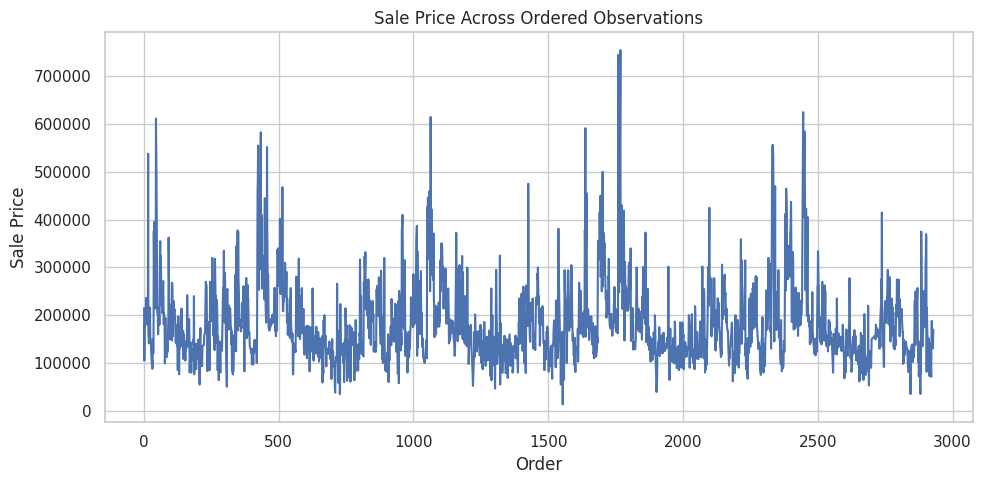

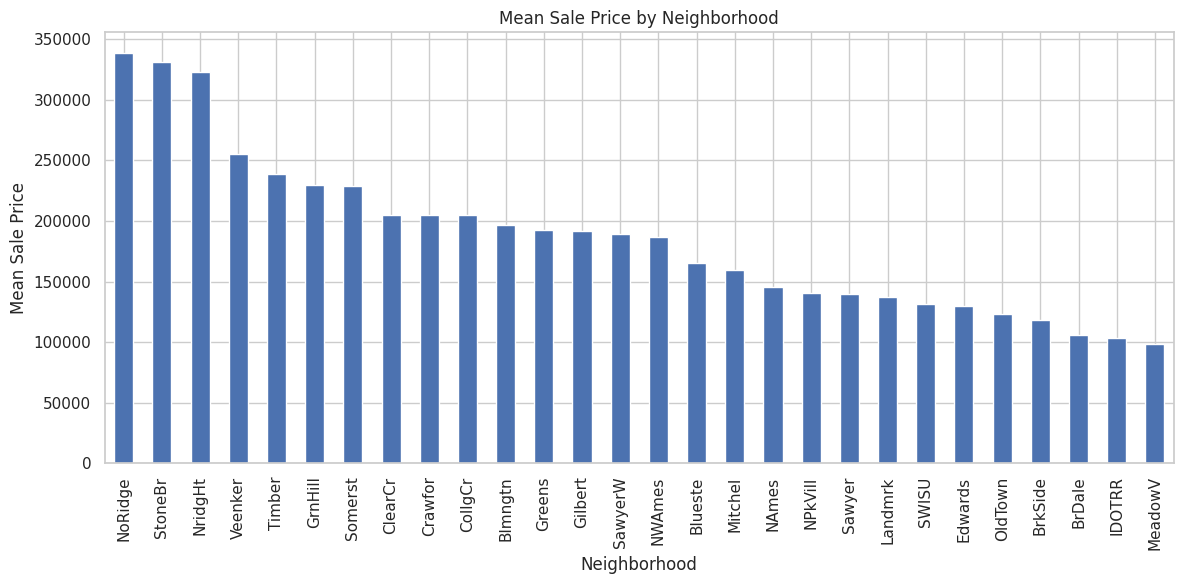

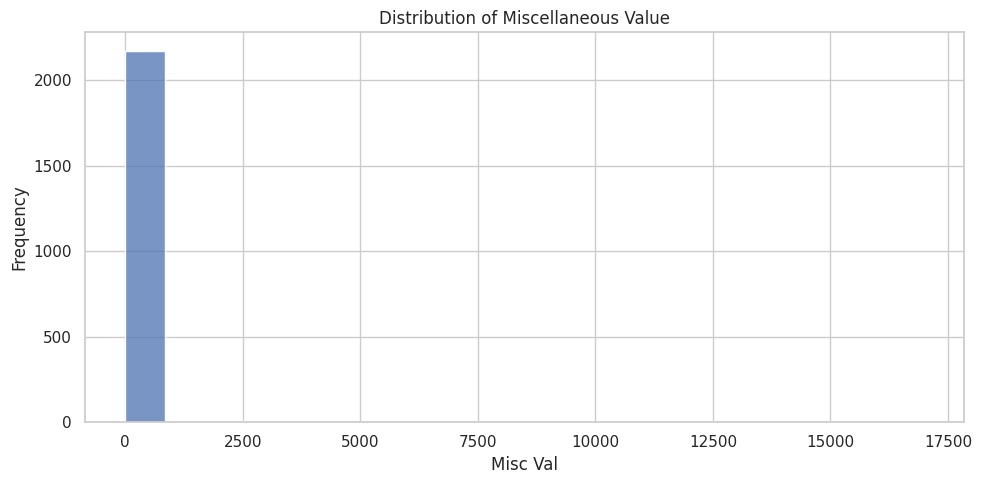

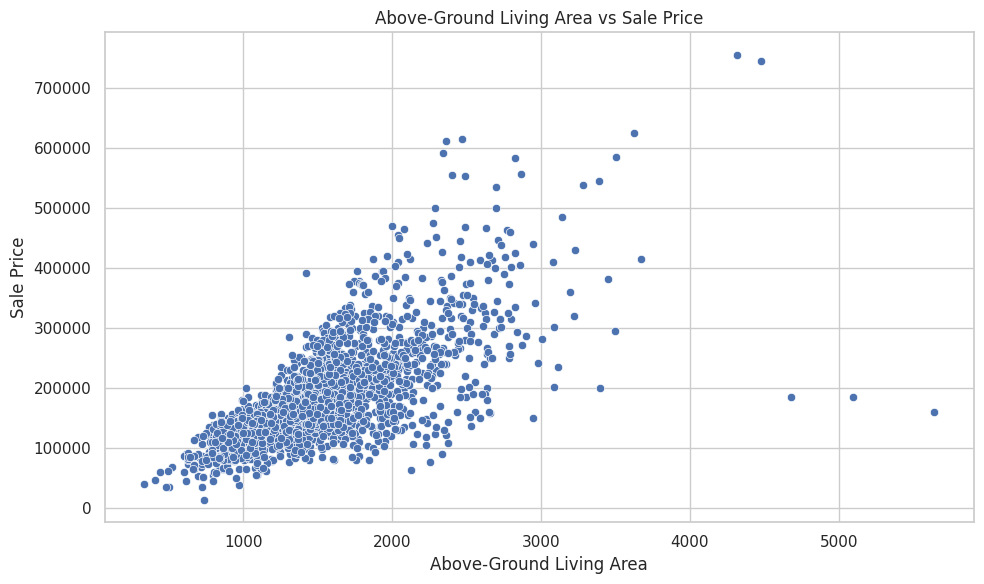

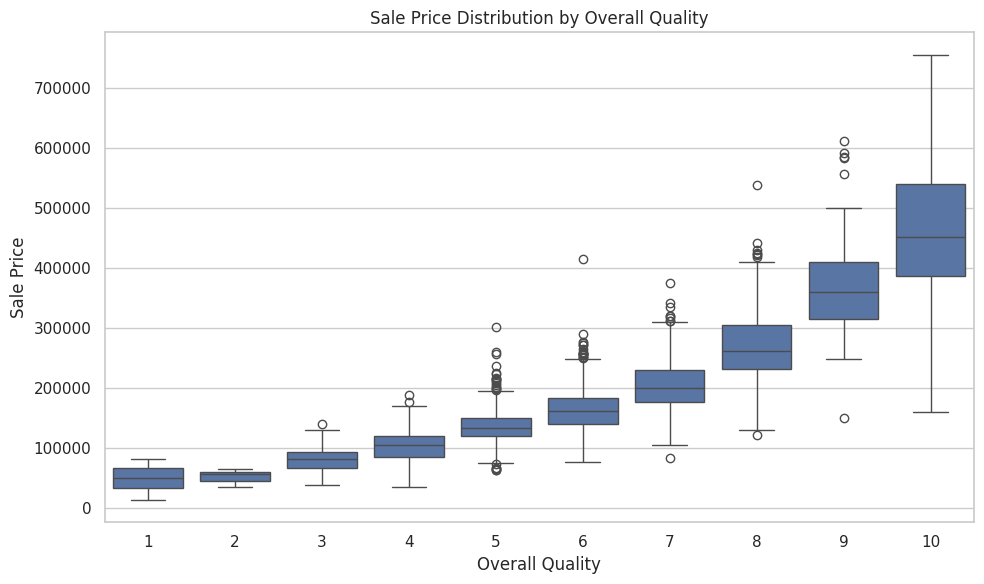

In [10]:
# Task 7: Visualizations

sns.set_theme(style="whitegrid")

# 1. Line Plot
sorted_df = df.sort_values(by='Order')

plt.figure(figsize=(10, 5))
plt.plot(sorted_df['Order'], sorted_df['SalePrice'])
plt.title('Sale Price Across Ordered Observations')
plt.xlabel('Order')
plt.ylabel('Sale Price')
plt.tight_layout()
plt.show()


# 2. Bar Chart
neighborhood_mean_price = (
    df.groupby('Neighborhood', observed=True)['SalePrice']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
neighborhood_mean_price.plot.bar()
plt.title('Mean Sale Price by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Mean Sale Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# 3. Histogram of Most Skewed Numeric Column
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Misc Val', bins=20)
plt.title('Distribution of Miscellaneous Value')
plt.xlabel('Misc Val')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


# 4. Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice')
plt.title('Above-Ground Living Area vs Sale Price')
plt.xlabel('Above-Ground Living Area')
plt.ylabel('Sale Price')
plt.tight_layout()
plt.show()


# 5. Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Overall Qual', y='SalePrice')
plt.title('Sale Price Distribution by Overall Quality')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')
plt.tight_layout()
plt.show()

Pearson Correlation Matrix:
                    Order       PID  Lot Frontage  Lot Area  Overall Qual  Overall Cond  Year Built  Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  Bsmt Unf SF  Total Bsmt SF  1st Flr SF  2nd Flr SF  Low Qual Fin SF  Gr Liv Area  Bsmt Full Bath  Bsmt Half Bath  Full Bath  Half Bath  Bedroom AbvGr  Kitchen AbvGr  TotRms AbvGrd  Fireplaces  Garage Yr Blt  Garage Cars  Garage Area  Wood Deck SF  Open Porch SF  Enclosed Porch  3Ssn Porch  Screen Porch  Pool Area  Misc Val   Mo Sold   Yr Sold  SalePrice
Order            1.000000  0.189937     -0.008558  0.037446     -0.062562     -0.026461   -0.054969       -0.078149     -0.040922     -0.034233      0.007742     0.006745      -0.025480   -0.005223   -0.008131         0.014993    -0.009562       -0.031707        0.005021  -0.044724  -0.035896       0.010533      -0.012146      -0.003007   -0.030540      -0.051207    -0.040592    -0.040978     -0.027334       0.005611        0.016182   -0.015998      0.0

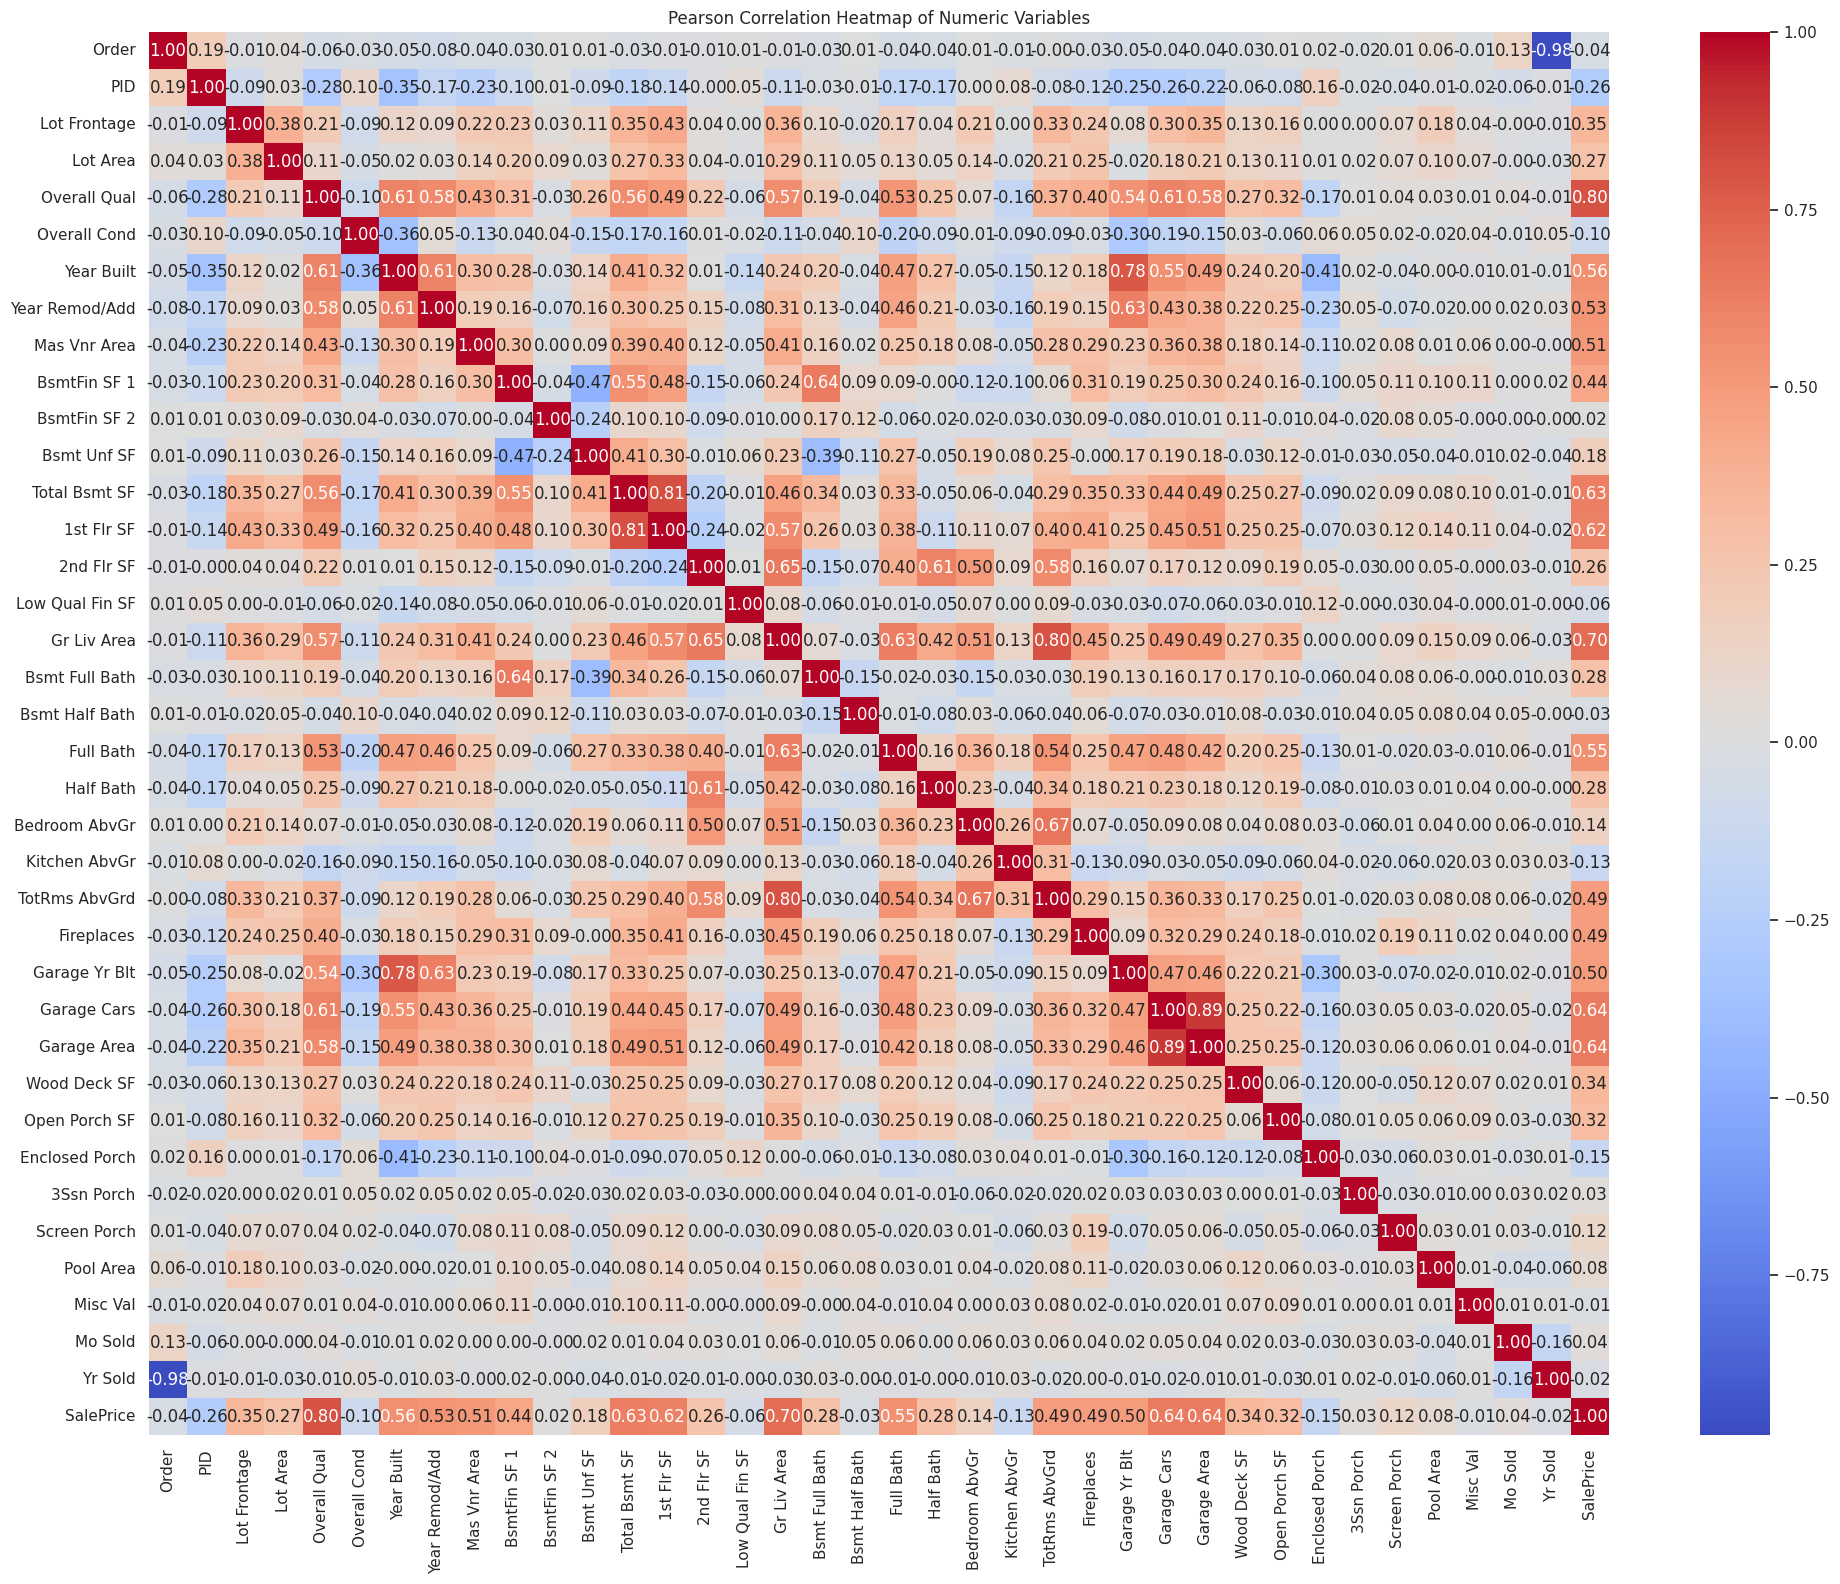


Pair with highest absolute correlation:
('Order', 'Yr Sold')

Pearson correlation value:
-0.9754891326043619


In [11]:
# Task 8: Pearson Correlation Heatmap

# Compute Pearson correlation matrix for all numeric columns
pearson_corr = df.corr(numeric_only=True)

print("Pearson Correlation Matrix:")
print(pearson_corr.to_string())

# Create correlation heatmap
plt.figure(figsize=(20, 16))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Pearson Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

# Find the pair with the highest absolute correlation
corr_abs = pearson_corr.abs()

# Remove self-correlations
np.fill_diagonal(corr_abs.values, np.nan)

highest_corr_pair = corr_abs.stack().idxmax()

highest_corr_value = pearson_corr.loc[
    highest_corr_pair[0],
    highest_corr_pair[1]
]

print("\nPair with highest absolute correlation:")
print(highest_corr_pair)

print("\nPearson correlation value:")
print(highest_corr_value)


In [12]:
# Task 9(a): Imputation Strategy Comparison

# Two numeric columns with highest absolute skewness
top_two_skew_columns = ['Misc Val', 'Pool Area']

print("Mean and Median Comparison Before Imputation:\n")

for col in top_two_skew_columns:
    column_mean = df[col].mean()
    column_median = df[col].median()
    column_skewness = df[col].skew()

    print("Column:", col)
    print("Mean:", column_mean)
    print("Median:", column_median)
    print("Skewness:", column_skewness)

    # Median chosen because both columns are positively skewed
    df[col] = df[col].fillna(column_median)

    print("-" * 40)

# Confirm null values in selected columns
print("\nNull values after imputation:")
print(df[top_two_skew_columns].isnull().sum())

Mean and Median Comparison Before Imputation:

Column: Misc Val
Mean: 57.404187528447885
Median: 0.0
Skewness: 20.167059981876903
----------------------------------------
Column: Pool Area
Mean: 2.7897132453345472
Median: 0.0
Skewness: 15.282789845954165
----------------------------------------

Null values after imputation:
Misc Val     0
Pool Area    0
dtype: int64


In [13]:
# Task 9(b): Spearman Rank Correlation

# Compute Spearman correlation matrix
spearman_corr = df.corr(method='spearman', numeric_only=True)

print("Pearson Correlation Matrix:")
print(pearson_corr.to_string())

print("\nSpearman Correlation Matrix:")
print(spearman_corr.to_string())

# Calculate absolute difference between Spearman and Pearson correlations
correlation_difference = (spearman_corr - pearson_corr).abs()

# Remove self-correlations and duplicate pairs
upper_triangle = correlation_difference.where(
    np.triu(np.ones(correlation_difference.shape), k=1).astype(bool)
)

# Identify three pairs with largest absolute difference
top_three_pairs = upper_triangle.stack().nlargest(3)

print("\nThree Column Pairs with Largest |Spearman - Pearson| Difference:\n")

for pair, difference in top_three_pairs.items():
    col1, col2 = pair

    pearson_value = pearson_corr.loc[col1, col2]
    spearman_value = spearman_corr.loc[col1, col2]

    print("Pair:", col1, "and", col2)
    print("Pearson Correlation:", pearson_value)
    print("Spearman Correlation:", spearman_value)
    print("|Spearman - Pearson|:", difference)

    if abs(spearman_value) > abs(pearson_value):
        print("Interpretation: Monotonic but potentially non-linear relationship.")
        print("Preferred measure for Part 2 feature-selection guidance: Spearman.")
    else:
        print("Interpretation: Relationship appears approximately linear.")
        print("Preferred measure for Part 2 feature-selection guidance: Pearson.")

    print("-" * 60)

Pearson Correlation Matrix:
                    Order       PID  Lot Frontage  Lot Area  Overall Qual  Overall Cond  Year Built  Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  Bsmt Unf SF  Total Bsmt SF  1st Flr SF  2nd Flr SF  Low Qual Fin SF  Gr Liv Area  Bsmt Full Bath  Bsmt Half Bath  Full Bath  Half Bath  Bedroom AbvGr  Kitchen AbvGr  TotRms AbvGrd  Fireplaces  Garage Yr Blt  Garage Cars  Garage Area  Wood Deck SF  Open Porch SF  Enclosed Porch  3Ssn Porch  Screen Porch  Pool Area  Misc Val   Mo Sold   Yr Sold  SalePrice
Order            1.000000  0.189937     -0.008558  0.037446     -0.062562     -0.026461   -0.054969       -0.078149     -0.040922     -0.034233      0.007742     0.006745      -0.025480   -0.005223   -0.008131         0.014993    -0.009562       -0.031707        0.005021  -0.044724  -0.035896       0.010533      -0.012146      -0.003007   -0.030540      -0.051207    -0.040592    -0.040978     -0.027334       0.005611        0.016182   -0.015998      0.0

In [15]:
# Task 9(c): Grouped Aggregation

# Choose one categorical column and one numeric column
categorical_col = 'Neighborhood'
numeric_col = 'SalePrice'

# Compute grouped aggregation
grouped_aggregation = df.groupby(
    categorical_col,
    observed=True
)[numeric_col].agg(['mean', 'std', 'count'])

# Print the grouped aggregation result
print("\nGrouped Aggregation:")
print(grouped_aggregation)

# Identify the group with the highest mean
highest_mean_group = grouped_aggregation['mean'].idxmax()
highest_mean_value = grouped_aggregation['mean'].max()

# Identify the group with the highest standard deviation
highest_std_group = grouped_aggregation['std'].idxmax()
highest_std_value = grouped_aggregation['std'].max()

print("\nGroup with Highest Mean:")
print(highest_mean_group, "-", highest_mean_value)

print("\nGroup with Highest Standard Deviation:")
print(highest_std_group, "-", highest_std_value)

# Within-group variance interpretation
print("\nWithin-Group Variance Interpretation:")
print(
    "A high within-group standard deviation indicates that SalePrice varies "
    "substantially among houses within the same Neighborhood. Therefore, "
    "Neighborhood alone may be insufficient to predict SalePrice reliably "
    "for members of that group."
)

# Compute ratio of highest group mean to lowest group mean
highest_group_mean = grouped_aggregation['mean'].max()
lowest_group_mean = grouped_aggregation['mean'].min()

mean_ratio = highest_group_mean / lowest_group_mean

print("\nRatio of Highest Group Mean to Lowest Group Mean:")
print(mean_ratio)

# Interpret the ratio
print("\nMean Ratio Interpretation:")

if mean_ratio >= 2:
    print(
        "The ratio is large, suggesting that Neighborhood carries "
        "predictive signal for SalePrice."
    )
else:
    print(
        "The ratio is not very large, suggesting that Neighborhood carries "
        "limited predictive signal for SalePrice."
    )


Grouped Aggregation:
                       mean            std  count
Neighborhood                                     
Blmngtn       196680.208333   26699.189616     24
Blueste       165000.000000   34166.260160      4
BrDale        106176.190476   11886.206492     21
BrkSide       117867.708333   34709.611354     72
ClearCr       204847.733333   48731.724097     30
CollgCr       204671.584906   53286.482945    212
Crawfor       204770.065789   64828.965218     76
Edwards       129568.362416   48012.357824    149
Gilbert       191657.330709   35331.837737    127
Greens        192375.000000   25272.391062      6
GrnHill       230000.000000            NaN      1
IDOTRR        103399.614286   35460.271356     70
Landmrk       137000.000000            NaN      1
MeadowV        98298.076923   21821.706995     26
Mitchel       159900.404494   40215.673290     89
NAmes         145474.021605   32759.276842    324
NPkVill       140492.105263    9524.300254     19
NWAmes        186945.761905 

In [17]:
# Final Categorical Missing Value Treatment

categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns

print("Categorical null values before imputation:")
print(df[categorical_columns].isnull().sum().to_string())

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode(dropna=True)[0]
        df[col] = df[col].fillna(mode_value)

print("\nCategorical null values after mode imputation:")
print(df[categorical_columns].isnull().sum().to_string())

print("\nTotal remaining null values:")
print(df.isnull().sum().sum())

Categorical null values before imputation:
MS SubClass         0
MS Zoning           0
Street              0
Lot Shape           0
Land Contour        0
Utilities           0
Lot Config          0
Land Slope          0
Neighborhood        0
Condition 1         0
Condition 2         0
Bldg Type           0
House Style         0
Roof Style          0
Roof Matl           0
Exterior 1st        0
Exterior 2nd        0
Exter Qual          0
Exter Cond          0
Foundation          0
Bsmt Qual          67
Bsmt Cond          67
Bsmt Exposure      69
BsmtFin Type 1     67
BsmtFin Type 2     68
Heating             0
Heating QC          0
Central Air         0
Electrical          1
Kitchen Qual        0
Functional          0
Garage Type       120
Garage Finish     122
Garage Qual       122
Garage Cond       122
Paved Drive         0
Sale Type           0
Sale Condition      0

Categorical null values after mode imputation:
MS SubClass       0
MS Zoning         0
Street            0
Lot Shape    

In [18]:
# Task 10: Save the Clean Dataset

df.to_csv('cleaned_data.csv', index=False)

print("Cleaned dataset saved successfully as cleaned_data.csv")
print("Final dataset shape:", df.shape)

print("\nTotal remaining null values:")
print(df.isnull().sum().sum())

Cleaned dataset saved successfully as cleaned_data.csv
Final dataset shape: (2197, 76)

Total remaining null values:
0
